We want to estimate the contribution of the individual terms to the 3-dim cloud fraction in specific regions.

Want a 4x4 table that we can copy into Latex.

In [1]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt

Load simulation data

In [2]:
sim_data_path = '/scratch/b/b309170/experiments/ag_atm_amip_r2b5_cvtfall_entrmid_05_cov15_based_on_12962670_240927_explicit_ix_terms'

# For just one month of data
# 1 chunks -> 97s
# 10 chunks -> 46s
# 50 chunks -> 36s
# 100 chunks -> 21s
# 1000 chunks -> 20s
# --> Can go with 1000 chunks

# Only with subset of full dataset first
DS = xr.open_mfdataset(f'{sim_data_path}/*atm_3d_ml*', \
                       combine='by_coords',
                       chunks={'time': 1000})  # adjust chunk size as needed

/tmp/ipykernel_4010996/3187951947.py:12: FutureWarning: In a future version of xarray the default value for data_vars will change from data_vars='all' to data_vars=None. This is likely to lead to different results when multiple datasets have matching variables with overlapping values. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set data_vars explicitly.
  DS = xr.open_mfdataset(f'{sim_data_path}/*atm_3d_ml*', \


In [3]:
vgrid = xr.open_dataset('/work/bd1179/b309170/icon-ml_models/icon-a-ml/experiments/ag_atm_amip_r2b5_iconaml_from_icona_20yrs/ag_atm_amip_r2b5_iconaml_from_icona_20yrs_atm_vgrid_ml.nc')
height_avrg = np.mean(vgrid.zg.values, axis=1)

Regions as in fig_3_and_S5_biases/compare_icon_ml_to_icon_a_tuned.ipynb

clat in -pi/2, pi/2 <br>
clon in -pi, pi

In compare_icon_ml_to_icon_a_tuned.ipynb war lat in [-90, 90] und lon in [0, 360], hier lat erstmal in [-90, 90] und lon in [-180, 180]

In [4]:
rad = np.pi / 180.0

# clat, clon boundaries for regions
regions = dict(
    GLOBAL = (None, None),
    SO = ((-65*rad, -45*rad), (-180*rad, 180*rad)),
    CHI = ((-30*rad, -10*rad), ((265-360)*rad, (285-360)*rad)),
    NAM = ((-30*rad, -10*rad), (-10*rad, 10*rad)), #!
    CAL = ((15*rad, 35*rad), ((220-360)*rad, (240-360)*rad)),
    MOR = ((10*rad, 30*rad), ((315-360)*rad, (335-360)*rad)),
    AUS = ((-40*rad, -20*rad), (90*rad, 110*rad)),
)

In [5]:
def region_means_lazy(ds, lat_bounds_lon_bounds):
    ''' 
        Compute region means of i1, i2, i3 terms lazily using xarray and dask.
        ds: xarray Dataset with 'clat' and 'clon' coordinates and i1_clc_term, i2_clc_term, i3_clc_term variables.
        lat_bounds_lon_bounds: tuple of (lat_bounds, lon_bounds), where each is a tuple (min, max) in radians.
                               If lat_bounds is None, selects global data.
        Returns: xarray Dataset with mean values of i1_clc_term, i2_clc_term, i3_clc_term over the specified region.
    '''
    lat_bounds, lon_bounds = lat_bounds_lon_bounds
    if lat_bounds is None:
        sel = ds  # global
    else:
        mask =  (ds['clat'] >= lat_bounds[0]) & (ds['clat'] <= lat_bounds[1]) & \
                (ds['clon'] >= lon_bounds[0]) & (ds['clon'] <= lon_bounds[1])
        # Compute ONLY the mask. This loads the small boolean array into memory.
        compute_mask = mask.compute() 
        # use .where with slices (lazy); if lon wraps you can handle separately
        sel = ds.where(compute_mask, drop=True)
    # clip using xarray (keeps dask lazy), then mean over all spatial+time dims
    clipped = sel[['i1_clc_term', 'i2_clc_term', 'i3_clc_term']].clip(min=-100, max=100)
    # specify dims to average over (adjust names if different)
    means = clipped.mean(dim=[d for d in clipped.dims if d in ('time', 'clat', 'clon')], skipna=True)
    # returns a Dataset with three scalar DataArrays (lazy)
    return means

In [6]:
# create lazy computations for all regions
lazy_results = {name: region_means_lazy(DS, bounds) for name, bounds in regions.items()}

# flatten tasks into DataArray objects and call dask.compute once to execute reading only once
from dask import compute
tasks = []
task_keys = []
for rname, ds_mean in lazy_results.items():
    for var in ('i1_clc_term', 'i2_clc_term', 'i3_clc_term'):
        tasks.append(ds_mean[var])
        task_keys.append((rname, var))

computed = compute(*tasks)  # single graph execution -> faster

# reassemble into dict of numbers
results = {}
for (rname, var), val in zip(task_keys, computed):
    results.setdefault(rname, {})[var] = np.mean(val.values, axis=1) # Average over horizontal

In [9]:
# For the paper
import matplotlib

# Increase the general font size
matplotlib.rcParams['legend.fontsize'] = 'x-large'
matplotlib.rcParams['axes.labelsize'] = 'x-large' # For an axes xlabel and ylabel
matplotlib.rcParams['axes.titlesize'] = 'x-large'
matplotlib.rcParams['xtick.labelsize'] = 'xx-large'
matplotlib.rcParams['ytick.labelsize'] = 'xx-large'

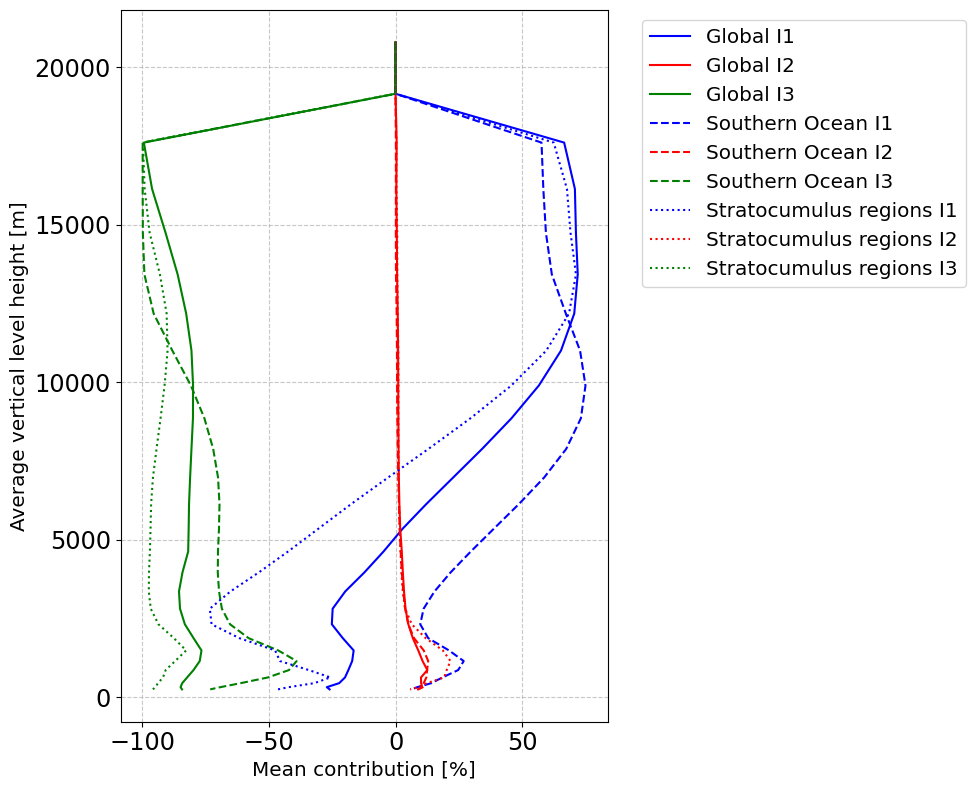

In [10]:
# Combine the stratocumulus regions
strato_regions = ['AUS', 'MOR', 'CAL', 'NAM', 'CHI']
combined_results = {
    'i1_clc_term': np.mean([results[region]['i1_clc_term'] for region in strato_regions], axis=0),
    'i2_clc_term': np.mean([results[region]['i2_clc_term'] for region in strato_regions], axis=0),
    'i3_clc_term': np.mean([results[region]['i3_clc_term'] for region in strato_regions], axis=0)
}

# Create a single figure
plt.figure(figsize=(10, 8))

cutoff = 20

# Plot all regions with different line styles
plt.plot(results['GLOBAL']['i1_clc_term'][cutoff:], height_avrg[cutoff:], '-', label='Global I1', color='blue')
plt.plot(results['GLOBAL']['i2_clc_term'][cutoff:], height_avrg[cutoff:], '-', label='Global I2', color='red')
plt.plot(results['GLOBAL']['i3_clc_term'][cutoff:], height_avrg[cutoff:], '-', label='Global I3', color='green')

plt.plot(results['SO']['i1_clc_term'][cutoff:], height_avrg[cutoff:], '--', label='Southern Ocean I1', color='blue')
plt.plot(results['SO']['i2_clc_term'][cutoff:], height_avrg[cutoff:], '--', label='Southern Ocean I2', color='red')
plt.plot(results['SO']['i3_clc_term'][cutoff:], height_avrg[cutoff:], '--', label='Southern Ocean I3', color='green')

plt.plot(combined_results['i1_clc_term'][cutoff:], height_avrg[cutoff:], ':', label='Stratocumulus regions I1', color='blue')
plt.plot(combined_results['i2_clc_term'][cutoff:], height_avrg[cutoff:], ':', label='Stratocumulus regions I2', color='red')
plt.plot(combined_results['i3_clc_term'][cutoff:], height_avrg[cutoff:], ':', label='Stratocumulus regions I3', color='green')

plt.xlabel('Mean contribution [%]')
plt.ylabel('Average vertical level height [m]')
# plt.title('Contribution of I1, I2, I3 terms')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, linestyle='--', alpha=0.7)
# plt.gca().invert_yaxis()

# Adjust the layout to prevent the legend from being cut off
plt.tight_layout()
plt.show()

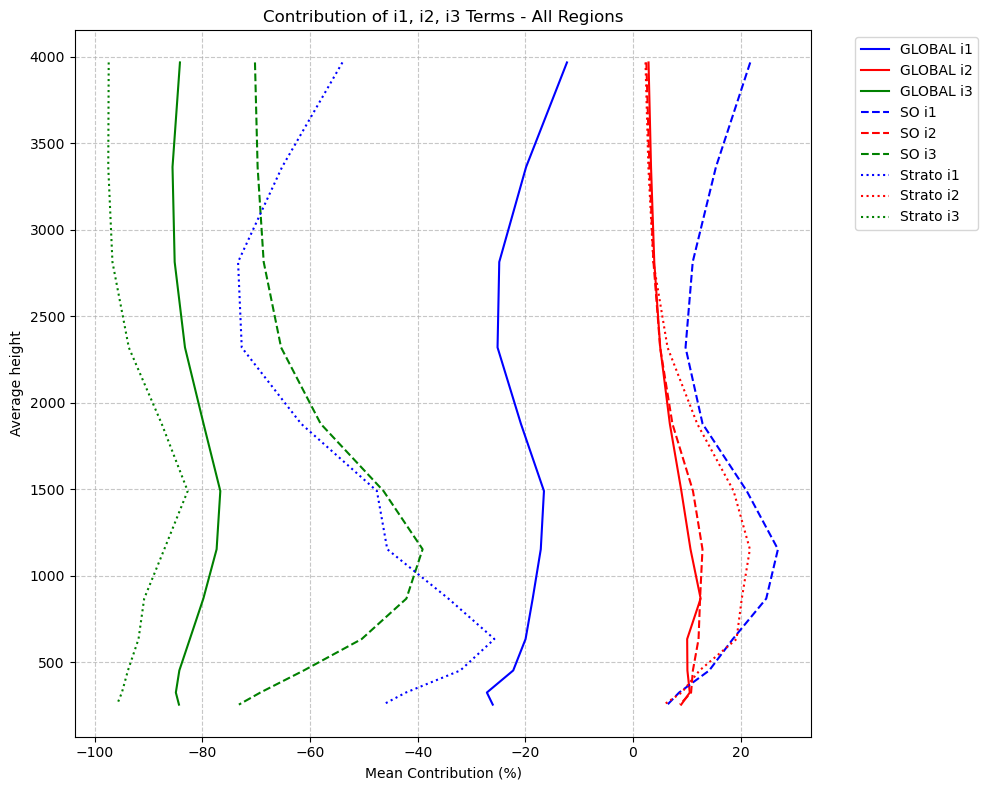

In [130]:
# Combine the stratocumulus regions
strato_regions = ['AUS', 'MOR', 'CAL', 'NAM', 'CHI']
combined_results = {
    'i1_clc_term': np.mean([results[region]['i1_clc_term'] for region in strato_regions], axis=0),
    'i2_clc_term': np.mean([results[region]['i2_clc_term'] for region in strato_regions], axis=0),
    'i3_clc_term': np.mean([results[region]['i3_clc_term'] for region in strato_regions], axis=0)
}

# Create a single figure
plt.figure(figsize=(10, 8))

cutoff = 35

# Plot all regions with different line styles
plt.plot(results['GLOBAL']['i1_clc_term'][cutoff:], height_avrg[cutoff:], '-', label='GLOBAL i1', color='blue')
plt.plot(results['GLOBAL']['i2_clc_term'][cutoff:], height_avrg[cutoff:], '-', label='GLOBAL i2', color='red')
plt.plot(results['GLOBAL']['i3_clc_term'][cutoff:], height_avrg[cutoff:], '-', label='GLOBAL i3', color='green')

plt.plot(results['SO']['i1_clc_term'][cutoff:], height_avrg[cutoff:], '--', label='SO i1', color='blue')
plt.plot(results['SO']['i2_clc_term'][cutoff:], height_avrg[cutoff:], '--', label='SO i2', color='red')
plt.plot(results['SO']['i3_clc_term'][cutoff:], height_avrg[cutoff:], '--', label='SO i3', color='green')

plt.plot(combined_results['i1_clc_term'][cutoff:], height_avrg[cutoff:], ':', label='Strato i1', color='blue')
plt.plot(combined_results['i2_clc_term'][cutoff:], height_avrg[cutoff:], ':', label='Strato i2', color='red')
plt.plot(combined_results['i3_clc_term'][cutoff:], height_avrg[cutoff:], ':', label='Strato i3', color='green')

plt.xlabel('Mean Contribution (%)')
plt.ylabel('Average height')
plt.title('Contribution of i1, i2, i3 Terms - All Regions')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, linestyle='--', alpha=0.7)
# plt.gca().invert_yaxis()

# Adjust the layout to prevent the legend from being cut off
plt.tight_layout()
plt.show()

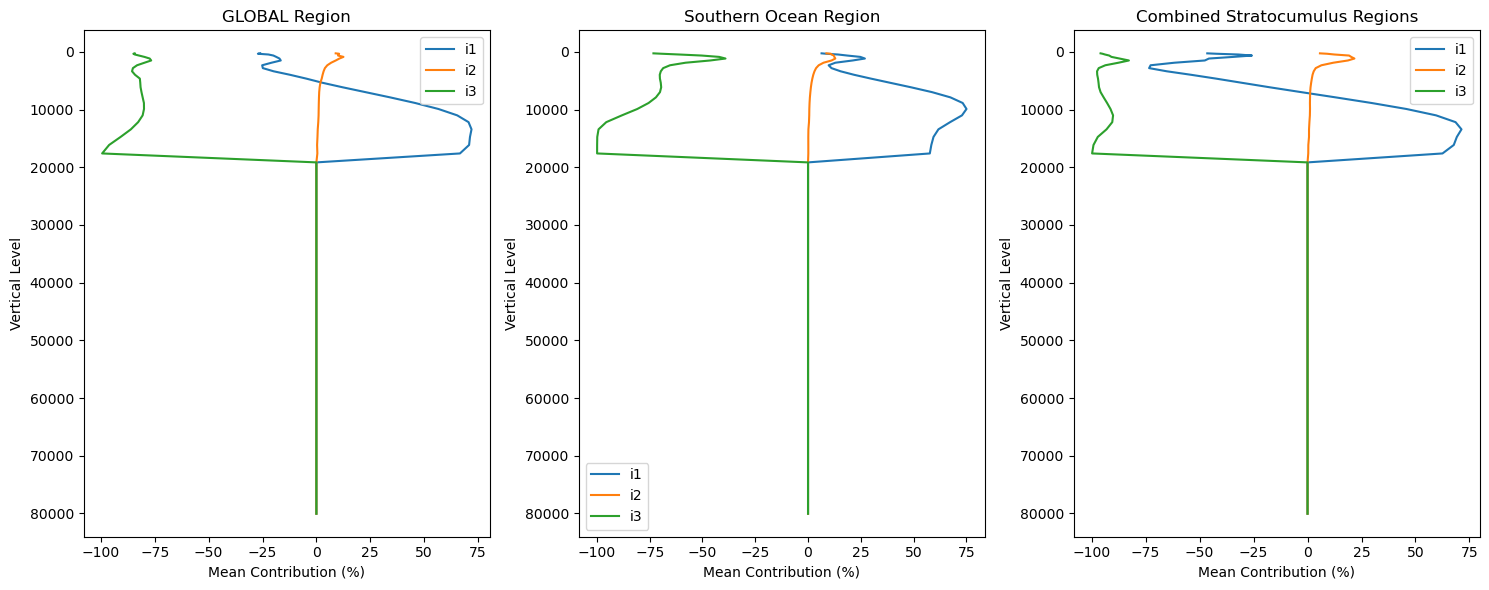

In [131]:
# Combine the stratocumulus regions
strato_regions = ['AUS', 'MOR', 'CAL', 'NAM', 'CHI']
combined_results = {
    'i1_clc_term': np.mean([results[region]['i1_clc_term'] for region in strato_regions], axis=0),
    'i2_clc_term': np.mean([results[region]['i2_clc_term'] for region in strato_regions], axis=0),
    'i3_clc_term': np.mean([results[region]['i3_clc_term'] for region in strato_regions], axis=0)
}

# Create a figure with subplots for the regions
fig, axs = plt.subplots(1, 3, figsize=(15, 6))

# Plot GLOBAL
axs[0].plot(results['GLOBAL']['i1_clc_term'], height_avrg, label='i1')
axs[0].plot(results['GLOBAL']['i2_clc_term'], height_avrg, label='i2')
axs[0].plot(results['GLOBAL']['i3_clc_term'], height_avrg, label='i3')
axs[0].set_xlabel('Mean Contribution (%)')
axs[0].set_ylabel('Vertical Level')
axs[0].set_title('GLOBAL Region')
axs[0].legend()
axs[0].invert_yaxis()

# Plot SO
axs[1].plot(results['SO']['i1_clc_term'], height_avrg, label='i1')
axs[1].plot(results['SO']['i2_clc_term'], height_avrg, label='i2')
axs[1].plot(results['SO']['i3_clc_term'], height_avrg, label='i3')
axs[1].set_xlabel('Mean Contribution (%)')
axs[1].set_ylabel('Vertical Level')
axs[1].set_title('Southern Ocean Region')
axs[1].legend()
axs[1].invert_yaxis()

# Plot combined stratocumulus regions
axs[2].plot(combined_results['i1_clc_term'], height_avrg, label='i1')
axs[2].plot(combined_results['i2_clc_term'], height_avrg, label='i2')
axs[2].plot(combined_results['i3_clc_term'], height_avrg, label='i3')
axs[2].set_xlabel('Mean Contribution (%)')
axs[2].set_ylabel('Vertical Level')
axs[2].set_title('Combined Stratocumulus Regions')
axs[2].legend()
axs[2].invert_yaxis()

# Adjust the layout to prevent overlapping
plt.tight_layout()
plt.show()

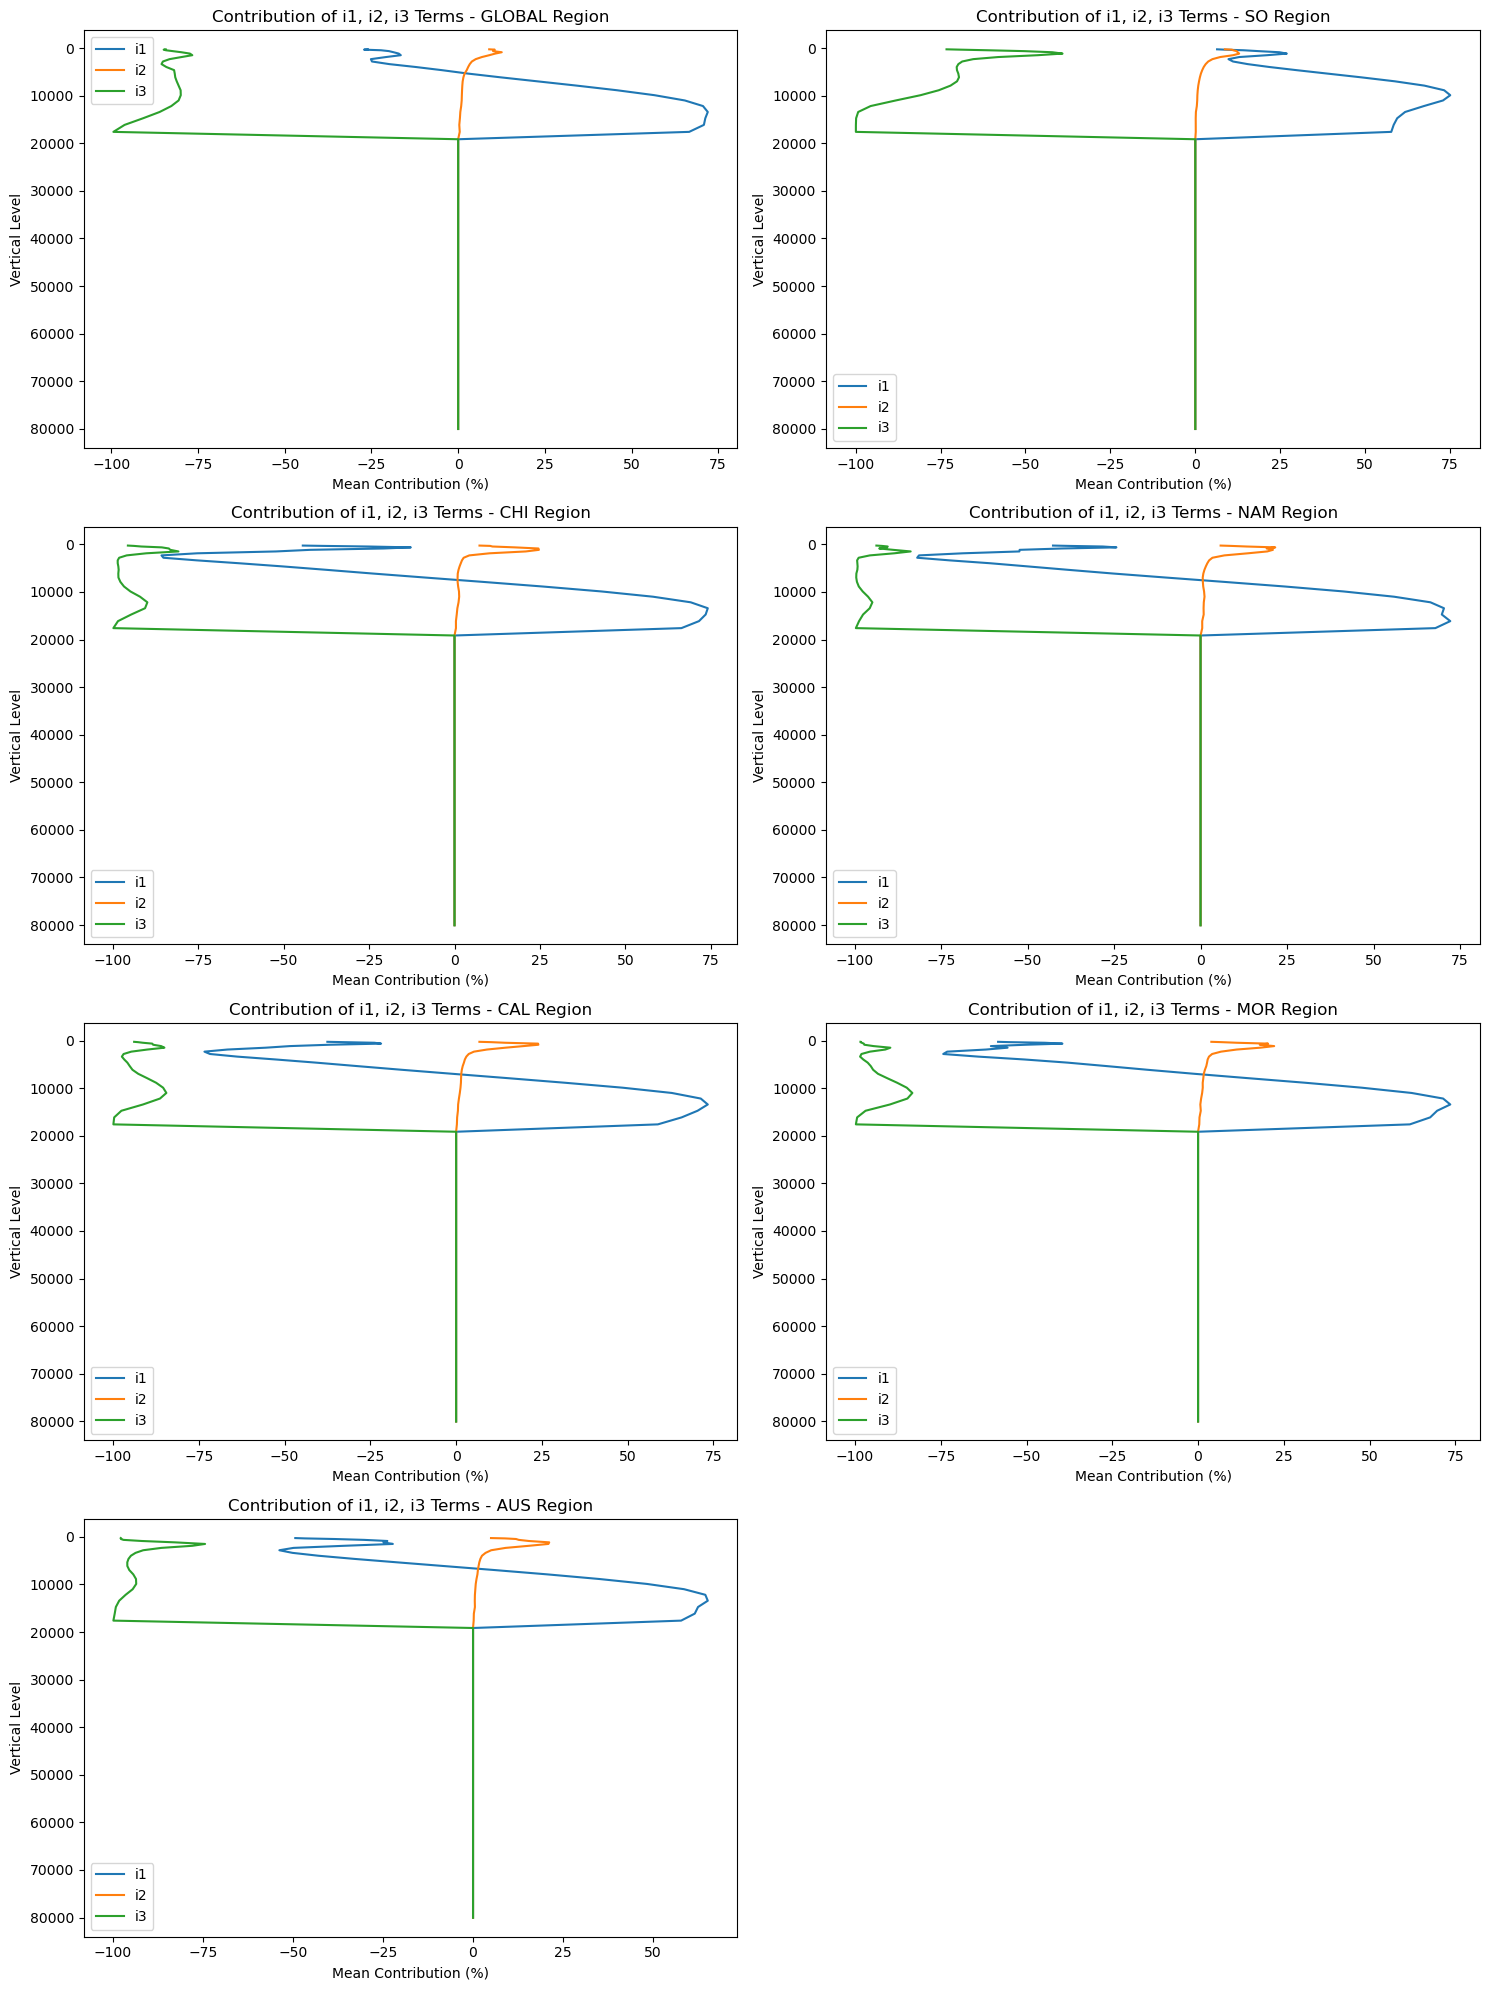

In [132]:
# Create a figure with subplots for all regions
fig, axs = plt.subplots(4, 2, figsize=(15, 20))
axs = axs.flatten()  # Flatten the 2D array of axes for easier indexing

# Plot each region
for idx, region in enumerate(regions.keys()):
    ax = axs[idx]
    ax.plot(results[region]['i1_clc_term'], height_avrg, label='i1')
    ax.plot(results[region]['i2_clc_term'], height_avrg, label='i2')
    ax.plot(results[region]['i3_clc_term'], height_avrg, label='i3')
    ax.set_xlabel('Mean Contribution (%)')
    ax.set_ylabel('Vertical Level')
    ax.set_title(f'Contribution of i1, i2, i3 Terms - {region} Region')
    ax.legend()
    ax.invert_yaxis()

# Remove the last subplot since we only have 7 regions
fig.delaxes(axs[-1])

# Adjust the layout to prevent overlapping
plt.tight_layout()
plt.show()

In [133]:
# reassemble into dict of numbers
results = {}
for (rname, var), val in zip(task_keys, computed):
    results.setdefault(rname, {})[var] = float(np.mean(val))

# print nicely
for rname in regions.keys():
    vals = results[rname]
    print(f"{rname}: i1 {vals['i1_clc_term']:.1f}%, i2 {vals['i2_clc_term']:.1f}%, i3 {vals['i3_clc_term']:.1f}%")

GLOBAL: i1 7.1%, i2 2.3%, i3 -44.3%
SO: i1 20.4%, i2 2.4%, i3 -38.4%
CHI: i1 -5.3%, i2 3.2%, i3 -49.8%
NAM: i1 -6.2%, i2 3.2%, i3 -50.8%
CAL: i1 -3.7%, i2 3.2%, i3 -49.0%
MOR: i1 -5.7%, i2 3.1%, i3 -50.1%
AUS: i1 -1.1%, i2 3.1%, i3 -49.7%
